# CLASSIFICATIONS PROBABILISTES

Le but de ce projet est d'étudier les méthodes de classifications auxquelles les statistiques donnent accès naturellement. Il s'agira donc d'étudier les outils de classifications probabilistes. C'est bien évidemment une petite partie de l'ensemble des méthodes de classification existant.


In [4]:
%load_ext autoreload
%autoreload 2

import pandas as pd # package for high-performance, easy-to-use data structures and data analysis
import numpy as np # fundamental package for scientific computing with Python
  
# utils.py contient des fonctions et des classes d'aide au tme9. IL NE FAUT RIEN CHANGER DANS CE FICHIER
# liste des classes et fonctions de ce fichier :
#  - getNthDict (remplit un dictionnaire avec la ligne n d'un dataframe)
#  - viewData (visualisation d'un dataframe)
#  - discretizeData (discrétisation automatique)
#  - AbstractClassifier (classe abstraite pour tous les classifieurs)
#  - drawGraphHorizontal (dessin d'un graphe orienté horizontal)
#  - drawGraph (dessin d'un graphe orienté vertical)
import utils

import tme9

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
train=pd.read_csv("data/train.csv")
test=pd.read_csv("data/test.csv")

Le tme8 avait fini par proposer des classifeurs ML et MAP à 2 dimensions qui utilisaient soit la vraisemblance $P(attr=a|target=t)$, soit la distribution a posteriori $P(target=t|attr=a)$. Ils ne prenaient donc en compte qu'un seul attribut parmi tous les attributs possibles. 

## 3- Complexités

On peut bien sûr se dire que les classifieurs ont intérêt à utiliser le plus d'information possible. Il serait donc pertinent de construire les classifieurs `ML3DClassifier`, `MAP3DClassifier`, ..., `ML14DClassifier` et `MAP14DClassifier` où les `...(x)DClassifier` prendrait $x-1$ attributs pour construire la prédiction de `target`. 

Toutefois, un problème va nous arrêter : les tables $P14Da$ et $P14Db$ sont de bien trop grande tailles !! 

### Question 3.1 : complexité en mémoire

Écrire une fonction `nbParams` qui affiche la taille mémoire de ces tables $P(target|attr_1,..,attr_k)$ étant donné un dataframe et la liste $[target,attr_1,...,attr_l]$ en supposant qu'un float est représenté sur 8octets. Si la liste des attributs n'est pas fourni, cette fonction doit considérer qu'on utilise tous les attributs disponibles

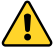 La fonction affiche le résultat en Go,Mo,Ko etc. mais retourn le nombre d'octets !

In [40]:
tme9.nbParams(train,['target'])
tme9.nbParams(train,['target','thal'])
tme9.nbParams(train,['target','age'])
tme9.nbParams(train,['target','age','thal','sex','exang'])
tme9.nbParams(train,['target','age','thal','sex','exang','slope','ca','chol'])
tme9.nbParams(train) # seul résultat visible en sortie de cellule

1 varibales : 16 octets
2 varibales : 64 octets
2 varibales : 208 octets
5 varibales : 3328 octets
8 varibales : 798720 octets
14 varibales : 58657996800 octets


58657996800

On ne peut donc pas manipuler de telles tables et il faut trouver de nouvelles façon de représenter les distributions de probabilités, quitte à en faire des approximations. 

La meilleure façon de simplifier la représentation d'une distribution de probabilité est d'utiliser des hypothèses d'indépendances. Ainsi, dans une loi jointe des variables $A,B,C,D,E$, si on suppose l'indépendance mutuelle de ces 5 variables, on sait qu'on pourra écrire que $$P(A,B,C,D,E)=P(A)*P(B)*P(C)*P(D)*P(E)$$ et donc remplacer un tableau à 5 dimensions par 5 tableaux monodimensionnels.

### Question 3.2 : complexité en mémoire sous hypothèse d'indépendance complète

Écrire une fonction `nbrParamsIndep` qui calcule la taille mémoire nécessaire pour représenter les tables de probabilité étant donné un dataframe, en supposant qu'un float est représenté sur 8octets et **en supposant l'indépendance des variables**.

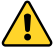 La fonction affiche le résultat et **rend la valeur calculée en octets** !

In [59]:
tme9.nbParamsIndep(train[['target']])
tme9.nbParamsIndep(train[['target','thal']])
tme9.nbParamsIndep(train[['target','age']])
tme9.nbParamsIndep(train[['target','age','thal','sex','exang']])
tme9.nbParamsIndep(train[['target','age','thal','sex','exang','slope','ca','chol']])
tme9.nbParamsIndep(train) # seul résultat visible en sortie de cellule

1 varibales : 16 octets
2 varibales : 48 octets
2 varibales : 120 octets
5 varibales : 184 octets
8 varibales : 376 octets
14 varibales : 800 octets


800

### Question 3.3 : indépendance conditionnelle

L'indépendance complète comme ci-dessus amène forcément à un classifier a priori (aucun attribut n'apporte d'information sur `target`).

Nous allons donc essayer de trouver des modèles supposant une certaine forme d'indépendance partielle qui permettra d'alléger quand même la représentation en mémoire de la distribution de probabilités. Ce sont les indépendances conditionnelles. Si l'on sait par exemple que $A$ est indépendant de $C$ sachant $B$, on peut écrire la loi jointe :
$$P(A,B,C)=P(A)*P(B|A)*P(C|B)$$

#### Question 3.3.a : preuve
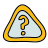 Pouvez vous le prouvez ?

Cette question ouverte doit donc être répondue dans `tme9.py` sous la forme :

> ```python
> #####
> # Question 3.3a
> #####
> # P(A,B,C)=...
> #####
> ```


#### Question 3.3.b : complexité en indépendance partielle

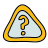 Si les 3 variables $A$, $B$ et $C$ ont $5$ valeurs, quelle est la taille mémoire en octet nécessaire pour représenter cette distribution avec et sans l'utilisation de l'indépendance conditionnelle ?

Cette question ouverte doit donc être répondue dans `tme9.py` sous la forme :

> ```python
> #####
> # Question 3.3b
> #####
> # ...
> #####
> ```


## 4- Représentation des indépendances conditionnelles : Modèles graphiques

Afin de représenter efficacement les indépendances conditionnelles utilisées pour représenter une distribution jointe de grande taille, on peut utiliser un graphe orienté qui se lit ainsi : dans la décomposition de la loi jointe, chaque variable $X$ apparaitra dans un facteur de la forme $P(X|Parents_X)$.  On note que cette factorisation n'a de sens que si le graphe n'a pas de circuit (c'est un DAG).

Ainsi, on représente la factorisation $P(A,B,C)=P(A)*P(B|A)*P(C|B)$ par le graphe suivant : $A$ n'a pas de parent, $B$ a pour parent $A$ et $C$ a pour parent $B$.

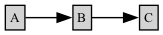

In [5]:
utils.drawGraphHorizontal("A->B->C")

### Question 4.1 : Exemples

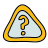 Proposer le code pour dessiner les graphes pour 5 variables $A,B,C,D,E$ complètement indépendantes puis pour ces 5 même variables sans aucune indépendance.

**Note** : une fonction qui dessine un graphe retourne un appel à `utils.drawGraph`, par exemple :

```python
def dessin_A_vers_B():
  return utils.drawGraph("A->B")

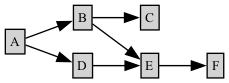

In [6]:
tme9.draw_5_variables_independantes() # le graphe A->B->C;A->D->E->F;B->E ci-dessous n'est pas le bon

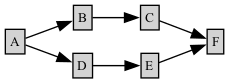

In [7]:
tme9.draw_5_variables_sans_independances() # le graphe A->B->C->F;A->D->E->F n'est pas le bon

### Question 4.2 : naïve Bayes

Un modèle simple souvent utilisée est le **Naïve Bayes**. Il suppose que $2$ attributs sont toujours indépendants conditionnellement à `target`.

Ce modèle est évidemment très simpliste et certainement faux. Toutefois, en classification, il donne souvent de bon résultats.

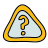

- Écrire comment se décompose la vraisemblance $P(attr1,attr2,attr3,\cdots|target)$.

- Écrire comment se décompose la distribution a posteriori $P(target|attr1,attr2,attr3,\cdots)$.

### Question 4.3 : modèle graphique et naïve bayes

Un modèle naïve bayes se représente sous la forme d'un graphe où le noeud `target` est l'unique parent de tous les attributs. 

#### Question 4.3.a

Construire une fonction `drawNaiveBayes` qui a partir d'un dataframe et du nom de la colonne qui est la classe, dessine le graphe. 

```

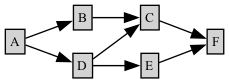

In [8]:
tme9.drawNaiveBayes(train,"target") # le graphe A->B->C->F;A->D->E->F;D->C n'est pas le bon

#### Question 4.3.b

Écrire une fonction `nbrParamsNaiveBayes` qui écrit la taille mémoire nécessaire pour représenter les tables de probabilité étant donné un dataframe, en supposant qu'un float est représenté sur 8octets et **en utilisant l'hypothèse du Naive Bayes**.

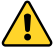 Comme plus haut, la fonction affiche le résultat et retourn le nombre d'octets !

In [9]:
tme9.nbParamsNaiveBayes(train,'target',[])
tme9.nbParamsNaiveBayes(train,'target',['target','thal'])
tme9.nbParamsNaiveBayes(train,'target',['target','age'])
tme9.nbParamsNaiveBayes(train,'target',['target','age','thal','sex','exang'])
tme9.nbParamsNaiveBayes(train,'target',['target','age','thal','sex','exang','slope','ca','chol'])
tme9.nbParamsNaiveBayes(train,'target') # seul résultat visible en sortie de cellule

0 variable(s) : 16 octets 
2 variable(s) : 80 octets 
2 variable(s) : 224 octets 
5 variable(s) : 352 octets 
8 variable(s) : 736 octets 
14 variable(s) : 1584 octets = 1ko 560o 


1584

On voit que l'augmentation de la mémoire nécessaire est très raisonnable.

### Question 4.4 : Classifieur naïve bayes

Écrire les classes `MLNaiveBayesClassifier` et `MAPNaiveBayesClassifier` qui utilise le maximum de vraisemblance (ML) et le maximum a posteriori (MAP) pour estimer la classe d'un individu en utilisant l'hypothèse du Naïve Bayes.

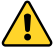 Vous aurez besoin de faire descendre ces classes de la classe `APrioriClassifier` du tme8 (pour récupérer la méthode `statsOnDF`): pensez à la recopier dans le tme9 !

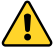 De la même façon que plus haut, penser à calculer tous les paramètres du Naïve Bayes dans le constructeur de la classe afin de ne pas les recalculer pour chaque classification.

Décomposer la méthodes `estimClass` en 2 parties : `estimProbas` qui calcule la vraisemblance ou la distribution a posteriori et `estimClass` qui utilise `estimProbas` pour choisir la classe comme dans les classifieurs précédents.

In [10]:
cl=tme9.MLNaiveBayesClassifier(train)

for i in [0,1,2]:
    print(f"Estimation de la proba de l'individu {i} par MLNaiveBayesClassifier : {cl.estimProbas(utils.getNthDict(train,i))}")
    print(f"Estimation de la classe de l'individu {i} par MLNaiveBayesClassifier : {cl.estimClass(utils.getNthDict(train,i))}") 
    print("------")
print(f"test en apprentissage : {cl.statsOnDF(train)}")
print(f"test en validation    : {cl.statsOnDF(test)}")

Estimation de la proba de l'individu 0 par MLNaiveBayesClassifier : {0: 5.265474022893808e-11, 1: 8.779438846356186e-12}
Estimation de la classe de l'individu 0 par MLNaiveBayesClassifier : 0
------
Estimation de la proba de l'individu 1 par MLNaiveBayesClassifier : {0: 0.0, 1: 1.9903404816168007e-09}
Estimation de la classe de l'individu 1 par MLNaiveBayesClassifier : 1
------
Estimation de la proba de l'individu 2 par MLNaiveBayesClassifier : {0: 3.6835223975945704e-10, 1: 1.5920340255297037e-06}
Estimation de la classe de l'individu 2 par MLNaiveBayesClassifier : 1
------
test en apprentissage : {'VP': 350, 'VN': 116, 'FP': 22, 'FN': 54, 'Précision': 0.9408602150537635, 'Rappel': 0.8663366336633663}
test en validation    : {'VP': 49, 'VN': 60, 'FP': 2, 'FN': 89, 'Précision': 0.9607843137254902, 'Rappel': 0.35507246376811596}


In [11]:
cl=tme9.MAPNaiveBayesClassifier(train)

for i in [0,1,2]:
    print(f"Estimation de la proba de l'individu {i} par MLNaiveBayesClassifier : {cl.estimProbas(utils.getNthDict(train,i))}")
    print(f"Estimation de la classe de l'individu {i} par MLNaiveBayesClassifier : {cl.estimClass(utils.getNthDict(train,i))}") 
    print("------")
print(f"test en apprentissage : {cl.statsOnDF(train)}")
print(f"test en validation    : {cl.statsOnDF(test)}")

Estimation de la proba de l'individu 0 par MLNaiveBayesClassifier : {0: 0.6719863008964104, 1: 0.3280136991035895}
Estimation de la classe de l'individu 0 par MLNaiveBayesClassifier : 0
------
Estimation de la proba de l'individu 1 par MLNaiveBayesClassifier : {0: 0.0, 1: 1.0}
Estimation de la classe de l'individu 1 par MLNaiveBayesClassifier : 1
------
Estimation de la proba de l'individu 2 par MLNaiveBayesClassifier : {0: 7.902679489883749e-05, 1: 0.9999209732051012}
Estimation de la classe de l'individu 2 par MLNaiveBayesClassifier : 1
------
test en apprentissage : {'VP': 382, 'VN': 111, 'FP': 27, 'FN': 22, 'Précision': 0.9339853300733496, 'Rappel': 0.9455445544554455}
test en validation    : {'VP': 53, 'VN': 57, 'FP': 5, 'FN': 85, 'Précision': 0.9137931034482759, 'Rappel': 0.38405797101449274}


## 5- *Feature selection* dans le cadre du classifier naive bayes

Il est possible qu'un attribut de la base ne soit pas important pour estimer la classe d'un individu. Dans le cadre du Naïve Bayes, un tel noeud se reconnaît car il est indépendant de `target`. Un tel noeud peut être supprimé du Naïve Bayes.

### Question 5.1

Écrire une fonction `isIndepFromTarget(df,attr,x)` qui vérifie si `attr` est indépendant de `target` au seuil de x%.

*Note* : vous avez le droit d'utiliser `scipy.stats.chi2_contingency` dans cette fonction.

In [12]:
for attr in train.keys():
    if attr!='target':
        print(f"target independant de {attr} ? {'YES' if tme9.isIndepFromTarget(train,attr,0.01) else 'no'}")

target independant de age ? no
target independant de sex ? no
target independant de cp ? no
target independant de trestbps ? YES
target independant de chol ? no
target independant de fbs ? YES
target independant de restecg ? no
target independant de thalach ? no
target independant de exang ? no
target independant de oldpeak ? no
target independant de slope ? no
target independant de ca ? no
target independant de thal ? no


### Question 5.2

Proposer des classes `ReducedMLNaiveBayesClassifier` et `ReducedMAPNaiveBayesClassifier` qui utilise cette indépendance pour minimiser le classifieur Naïve Bayes.

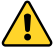 Ces classes devrait hériter des NaiveBayes précédent et ne redéfinir que la construction du classifieur.

Ajouter à ces deux classifiers une méthode `draw()` qui permet de dessiner le Naive Bayes contenant uniquement les variables finalement sélectionnées.

In [13]:
cl=tme9.ReducedMLNaiveBayesClassifier(train,0.05)
cl.draw() # ce n'est pas le bon graphe. Il ne doit y avoir que 12 features (et la target)

In [14]:
for i in [0,1,2]:
    print(f"Estimation de la proba de l'individu {i} par ReducedMLNaiveBayesClassifier : {cl.estimProbas(utils.getNthDict(train,i))}")
    print(f"Estimation de la classe de l'individu {i} par ReducedMLNaiveBayesClassifier : {cl.estimClass(utils.getNthDict(train,i))}") 
    print("------")
print(f"test en apprentissage : {cl.statsOnDF(train)}")
print(f"test en validation    : {cl.statsOnDF(test)}")

Estimation de la proba de l'individu 0 par ReducedMLNaiveBayesClassifier : {0: 3.3028882507242974e-10, 1: 5.2938705879520875e-11}


Estimation de la classe de l'individu 0 par ReducedMLNaiveBayesClassifier : 0
------
Estimation de la proba de l'individu 1 par ReducedMLNaiveBayesClassifier : {0: 0.0, 1: 2.386046156003523e-09}
Estimation de la classe de l'individu 1 par ReducedMLNaiveBayesClassifier : 1
------
Estimation de la proba de l'individu 2 par ReducedMLNaiveBayesClassifier : {0: 4.3821214730004375e-10, 1: 1.9085511760059353e-06}
Estimation de la classe de l'individu 2 par ReducedMLNaiveBayesClassifier : 1
------
test en apprentissage : {'VP': 350, 'VN': 116, 'FP': 22, 'FN': 54, 'Précision': 0.9408602150537635, 'Rappel': 0.8663366336633663}
test en validation    : {'VP': 49, 'VN': 60, 'FP': 2, 'FN': 89, 'Précision': 0.9607843137254902, 'Rappel': 0.35507246376811596}


In [15]:
cl=tme9.ReducedMLNaiveBayesClassifier(train,0.01)
cl.draw() # ce n'est pas le bon graphe. Il ne doit y avoir que 11 features (et la target)

In [16]:
for i in [0,1,2]:
    print(f"Estimation de la proba de l'individu {i} par ReducedMLNaiveBayesClassifier : {cl.estimProbas(utils.getNthDict(train,i))}")
    print(f"Estimation de la classe de l'individu {i} par ReducedMLNaiveBayesClassifier : {cl.estimClass(utils.getNthDict(train,i))}") 
    print("------")
print(f"test en apprentissage : {cl.statsOnDF(train)}")
print(f"test en validation    : {cl.statsOnDF(test)}")

Estimation de la proba de l'individu 0 par ReducedMLNaiveBayesClassifier : {0: 5.697482232499414e-09, 1: 2.1387237175326438e-09}
Estimation de la classe de l'individu 0 par ReducedMLNaiveBayesClassifier : 0
------
Estimation de la proba de l'individu 1 par ReducedMLNaiveBayesClassifier : {0: 0.0, 1: 1.1475745797921707e-08}
Estimation de la classe de l'individu 1 par ReducedMLNaiveBayesClassifier : 1
------
Estimation de la proba de l'individu 2 par ReducedMLNaiveBayesClassifier : {0: 2.7487852876093656e-09, 1: 9.179222322695213e-06}
Estimation de la classe de l'individu 2 par ReducedMLNaiveBayesClassifier : 1
------


test en apprentissage : {'VP': 348, 'VN': 117, 'FP': 21, 'FN': 56, 'Précision': 0.943089430894309, 'Rappel': 0.8613861386138614}
test en validation    : {'VP': 49, 'VN': 61, 'FP': 1, 'FN': 89, 'Précision': 0.98, 'Rappel': 0.35507246376811596}


In [17]:
cl=tme9.ReducedMAPNaiveBayesClassifier(train,0.01)
cl.draw() # ce n'est pas le bon graphe. Il ne doit y avoir que 11 features (et la target)

In [18]:
for i in [0,1,2]:
    print(f"Estimation de la proba de l'individu {i} par ReducedMAPNaiveBayesClassifier : {cl.estimProbas(utils.getNthDict(train,i))}")
    print(f"Estimation de la classe de l'individu {i} par ReducedMAPNaiveBayesClassifier : {cl.estimClass(utils.getNthDict(train,i))}") 
    print("------")
print(f"test en apprentissage : {cl.statsOnDF(train)}")
print(f"test en validation    : {cl.statsOnDF(test)}")

Estimation de la proba de l'individu 0 par ReducedMAPNaiveBayesClassifier : {0: 0.47643095845795097, 1: 0.5235690415420491}
Estimation de la classe de l'individu 0 par ReducedMAPNaiveBayesClassifier : 1
------
Estimation de la proba de l'individu 1 par ReducedMAPNaiveBayesClassifier : {0: 0.0, 1: 1.0}
Estimation de la classe de l'individu 1 par ReducedMAPNaiveBayesClassifier : 1
------
Estimation de la proba de l'individu 2 par ReducedMAPNaiveBayesClassifier : {0: 0.00010227941341238207, 1: 0.9998977205865877}
Estimation de la classe de l'individu 2 par ReducedMAPNaiveBayesClassifier : 1
------


test en apprentissage : {'VP': 375, 'VN': 110, 'FP': 28, 'FN': 29, 'Précision': 0.9305210918114144, 'Rappel': 0.9282178217821783}
test en validation    : {'VP': 53, 'VN': 56, 'FP': 6, 'FN': 85, 'Précision': 0.8983050847457628, 'Rappel': 0.38405797101449274}


## 6- Evaluation des classifieurs

Nous commençons à avoir pas mal de classifieurs. Pour les comparer, une possibilité est d'utiliser la représentation graphique des points $(précision,rappel)$ de chacun (la précision et le rappel sont des valeurs entre $0$ et $1$).

### Question 6.1

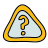 Où se trouve à votre avis le point idéal ? Comment pourriez-vous proposer de comparer les différents classifieurs dans cette représentation graphique ?

### Question 6.2 

Écrire une fonction `mapClassifiers(dic,df)` qui, à partir d'un dictionnaire `dic` de `{nom:instance de classifier}` et d'un dataframe `df`, représente graphiquement ces classifiers dans l'espace $(précision,rappel)$.

Vous devrez recopier tous les codes de TME8 pour avoir les différents classifieurs

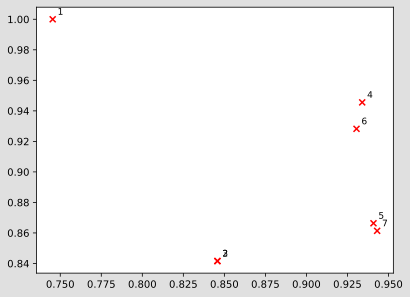

In [19]:
tme9.mapClassifiers({"1":tme9.APrioriClassifier(train),
                "2":tme9.ML2DClassifier(train,"exang"),
                "3":tme9.MAP2DClassifier(train,"exang"),
                "4":tme9.MAPNaiveBayesClassifier(train),
                "5":tme9.MLNaiveBayesClassifier(train),
                "6":tme9.ReducedMAPNaiveBayesClassifier(train,0.01),
                "7":tme9.ReducedMLNaiveBayesClassifier(train,0.01),
               },train)

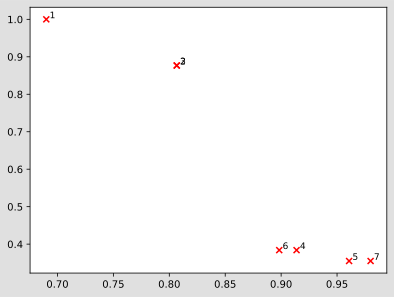

In [20]:
tme9.mapClassifiers({"1":tme9.APrioriClassifier(train),
                "2":tme9.ML2DClassifier(train,"exang"),
                "3":tme9.MAP2DClassifier(train,"exang"),
                "4":tme9.MAPNaiveBayesClassifier(train),
                "5":tme9.MLNaiveBayesClassifier(train),
                "6":tme9.ReducedMAPNaiveBayesClassifier(train,0.01),
                "7":tme9.ReducedMLNaiveBayesClassifier(train,0.01),
               },test)

### Question 6.3 : Conclusion

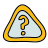 Qu'en concluez vous ?